In [1]:
import numpy as np 
import healpy as hp
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff
import glob
import seaborn as sns
# sns.set_style("darkgrid")
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from num2words import num2words as n2
from scipy.optimize import curve_fit
from mpl_toolkits import mplot3d
import os
from distfit import distfit
import sys
import scipy
import rasterio
from scipy.interpolate import CubicSpline
from scipy.integrate import quad
from scipy.stats import multivariate_normal
from country_choice import country_select
# sns.set(rc={"xtick.bottom": True, "ytick.left": True})
%matplotlib inline
# %matplotlib notebook

In [2]:
selval=country_select()

Select country: Russia
15508 Tx in total


## sample 5000 pixels from complete USA database

In [3]:
usa_data=pd.read_csv('./database/Russia.csv')
usa_data=usa_data.dropna()

In [4]:
train_lon=usa_data['Longitude in degrees'].to_numpy()
train_lat=usa_data['Latitude in degrees'].to_numpy()
power=usa_data['EIRP'].to_numpy()
frequency=usa_data['Frequency(MHz)'].to_numpy()

In [5]:
valididx=np.nonzero(power)

In [6]:
train_lon=train_lon[valididx]
train_lat=train_lat[valididx]
power=power[valididx]
frequency=frequency[valididx]
train_pix=hp.ang2pix(128,train_lon,train_lat,lonlat=True)

In [7]:
finval=selval-len(train_lon)

## CDF of pixels

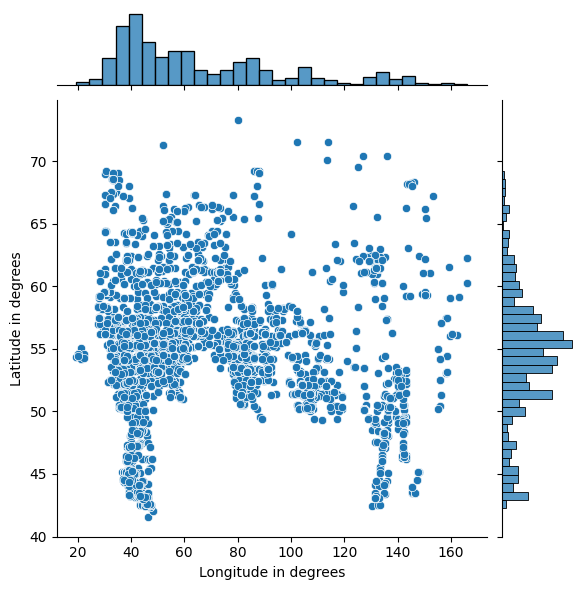

In [8]:
sns.jointplot(x='Longitude in degrees',y='Latitude in degrees',data=usa_data)
plt.show()

In [9]:
# Bin width using Freedman Diaconis rule
def FDrule(data):
    # Calculate interquartile range
    iqr = np.percentile(data, 75) - np.percentile(data, 25)
    
    # Calculate Freedman-Diaconis bin width
    n = len(data)
    bin_width = 2 * iqr / (n ** (1/3))

    # Calculate number of bins
    data_range = max(data) - min(data)
    num_bins = int(data_range / bin_width) + 1
    
    return num_bins

## 2D histogram sampling

In [10]:
data=np.column_stack((train_lon,train_lat))

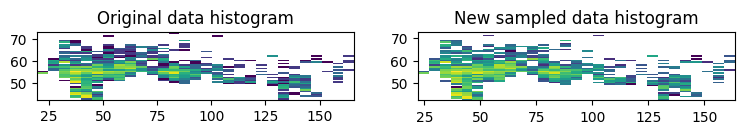

In [11]:
### from mpl_toolkits.axes_grid1 import make_axes_locatable
np.random.seed(42)


x, y = data.T
BIN_COUNT1 = FDrule(x)
BIN_COUNT2=FDrule(y)
hist, x_bins, y_bins = np.histogram2d(x, y, bins=(BIN_COUNT1, BIN_COUNT2))
x_bin_midpoints = (x_bins[:-1] + x_bins[1:])/2
y_bin_midpoints = (y_bins[:-1] + y_bins[1:])/2

cdf = np.cumsum(hist.flatten())
cdf = cdf / cdf[-1]

values = np.random.rand(finval)
value_bins = np.searchsorted(cdf, values)
x_idx, y_idx = np.unravel_index(value_bins,
                                (len(x_bin_midpoints),
                                 len(y_bin_midpoints)))
random_from_cdf = np.column_stack((x_bin_midpoints[x_idx],
                                   y_bin_midpoints[y_idx]))
new_x, new_y = random_from_cdf.T


fig, axs = plt.subplots(1, 2, figsize=(9, 3))

axs[0].hist2d(x, y, bins=(BIN_COUNT1, BIN_COUNT2),norm='log')
axs[0].set_title('Original data histogram')
axs[1].hist2d(new_x, new_y, bins=(BIN_COUNT1, BIN_COUNT2),norm='log')
axs[1].set_title('New sampled data histogram')
for ax in axs:    
    ax.set(aspect='equal')



## Model power using global data and assign to transmitters using the distribution

In [12]:
# Different power distributions for different pixel ranges
data2=np.column_stack((train_lon,train_lat,power))

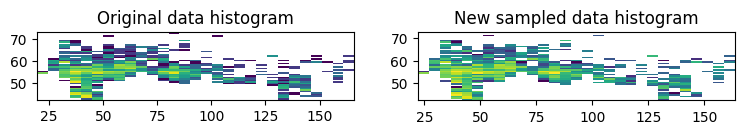

In [13]:
x, y,z = data2.T
BIN_COUNT1 = FDrule(x)
BIN_COUNT2=FDrule(y)
BIN_COUNT3=FDrule(z)

hist, bins = np.histogramdd(data2, bins=(BIN_COUNT1, BIN_COUNT2,BIN_COUNT3))
x_bins=bins[0]
y_bins=bins[1]
z_bins=bins[2]


x_bin_midpoints = (x_bins[:-1] + x_bins[1:])/2
y_bin_midpoints = (y_bins[:-1] + y_bins[1:])/2
z_bin_midpoints = (z_bins[:-1] + z_bins[1:])/2

cdf = np.cumsum(hist.flatten())
cdf = cdf / cdf[-1]

values = np.random.rand(finval)
value_bins = np.searchsorted(cdf, values)
x_idx, y_idx ,z_idx= np.unravel_index(value_bins,
                                (len(x_bin_midpoints),
                                 len(y_bin_midpoints),len(z_bin_midpoints)))
random_from_cdf = np.column_stack((x_bin_midpoints[x_idx],
                                   y_bin_midpoints[y_idx],z_bin_midpoints[z_idx]))

new_x, new_y,new_z = random_from_cdf.T


fig, axs = plt.subplots(1, 2, figsize=(9, 3))

axs[0].hist2d(x,y, bins=(BIN_COUNT1, BIN_COUNT2),norm='log')
axs[0].set_title('Original data histogram')
axs[1].hist2d(new_x, new_y, bins=(BIN_COUNT1, BIN_COUNT2),norm='log')
axs[1].set_title('New sampled data histogram')
for ax in axs:    
    ax.set(aspect='equal')


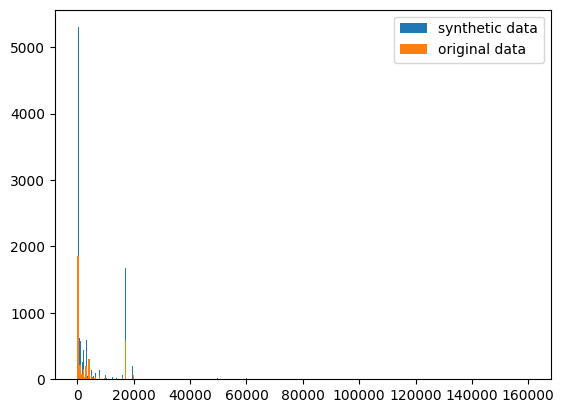

In [14]:
plt.hist(new_z,bins=FDrule(new_z),label='synthetic data')
plt.hist(power,bins=FDrule(power),label='original data')
plt.legend()
plt.show()

## Checking pixel wise median power trends

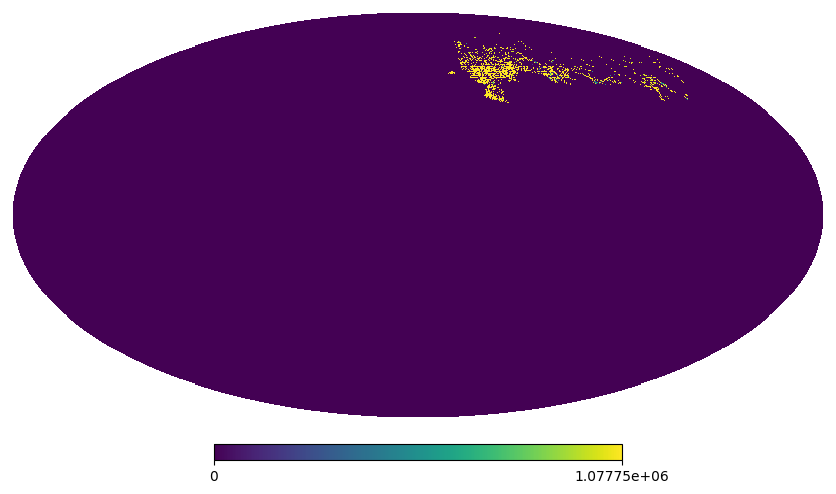

In [15]:
pixel_128=hp.ang2pix(128,train_lon,train_lat,lonlat=True)
Tx_pow_128=np.zeros(hp.nside2npix(128))
for index,p in enumerate(pixel_128):
    Tx_pow_128[p]+=(power[index])
hp.mollview(Tx_pow_128,flip='geo',cmap='viridis',title='',norm='hist')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper images/new_Txpow',dpi=600)


plt.show()

In [16]:
df = pd.DataFrame({'Pixel': pixel_128, 'Power': power})

# Calculate the median power values for each unique pixel index
median_power_values = df.groupby('Pixel')['Power'].median().values


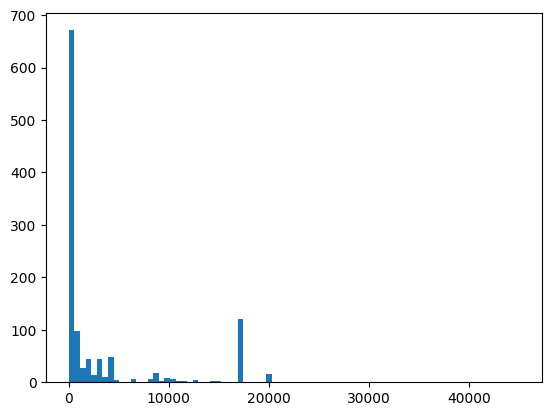

In [17]:
bins1=plt.hist(median_power_values,bins=FDrule(median_power_values))
plt.show()

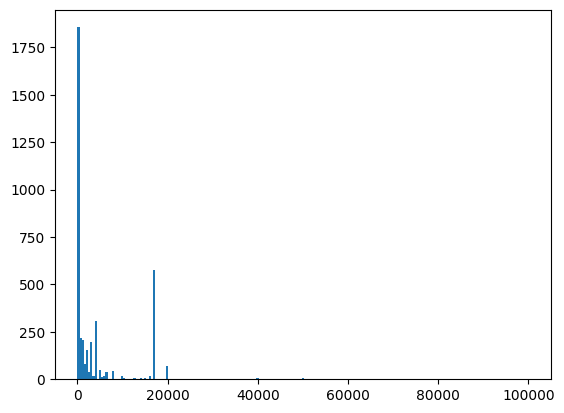

In [18]:
bins2=plt.hist(power[power<160000],bins=FDrule(power[power<160000]))
plt.show()